In [1]:
# Source - https://stackoverflow.com/a/5399339
# Posted by pv., modified by community. See post 'Timeline' for change history
# Retrieved 2026-02-26, License - CC BY-SA 4.0

%load_ext autoreload
%autoreload 2


In [2]:
import os
import sys
import yaml
import pickle
from pathlib import Path
from typing import Any, Dict

# Disable XLA preallocation to avoid hogging GPU memory
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from tqdm import tqdm
from absl import flags

import jax
import jax.numpy as jnp
from jax import config as jax_config
import optax
import haiku as hk
from flax.training.early_stopping import EarlyStopping
import wandb

import jax_cosmo as jc
from jaxpm.nn import CNN, NeuralSplineFourierFilter
from jaxpm.painting import compensate_cic
from jaxpm.utils import power_spectrum
from jaxpm.pm import get_delta

/cosmos_storage/home/diegovillalba/JaxPM/.venv/lib/python3.11/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


In [3]:
from pm2nbody.read_data import load_datasets
from pm2nbody.loss import (
    get_frozen_potential_loss,
    get_potential_loss,
    get_position_loss,
    get_mse_pos,
)

In [3]:

# --- Global Configurations ---
jax_config.update("jax_enable_x64", False)

mpl.rcParams.update(
    {
        "text.usetex": False,
        "font.family": "serif",
    }
)
mpl.rcParams["figure.dpi"] = 300
plt.style.use("default")

DEFAULT_DATA_DIR = Path("/cosmos_storage/home/diegovillalba/JaxPM/data/")
DEFAULT_MODEL_DIR = Path("/cosmos_storage/home/diegovillalba/JaxPM/models/")



In [4]:
# FLAGS = flags.FLAGS
# FLAGS(sys.argv)
cfg = {
        "data": {
            "mesh_lr": 128,
            "mesh_hr": 256,
            "n_train_sims": 1,
            "n_val_sims": 1,
            "n_test_sims": 1,
            "snapshots": None,
            "box_size": 256.0,
            "n_snapshots": 50,
            "n_particles": 128,
        },
        "correction_model": {
            "type": "cnn",
            "channels_hidden_dim": 16,
            "n_convolutions": 3,
            "n_fully_connected": 2,
            "input_dim": 1,
            "kernel_size": 3,
            "pad_periodic": True,
            "embed_globals": False,
            "n_globals_embedding": 1,
            "globals_embedding_dim": 64,
            "global_conditioning": "add",
            "use_attention_interpolation": False,
            "add_particle_velocities": True,
            "n_knots": 16,
            "latent_size": 64,
        },
        "training": {
            "seed": 0,
            "n_steps": 100,
            "batch_size": 1,
            "patience": 20,
            "checkpoint_every": 5,
            "sample_snapshots": True,
            "loss": "mse_potential",
            "weight_snapshots": True,
            "lambda_pos": 1.0,
            "lambda_velocity": 1.0,
            "lambda_density": 0.0,
            "lambda_pk": 0.0,
            "lambda_cross_corr": 0.0,
            "log_pos": False,
            "fractional_mse": False,
            "weight_decay": 1e-4,
            "schedule": {
                "type": "cosine",
                "initial_lr": 0.0,
                "peak_value": 3e-4,
                "warmup_steps": 50,
                "n_steps": 20_000,
                "factor": 0.5,
                "patience": 5,
                "min_lr": 1e-6,
            },
        },
        "wandb": {
            "project": "pm2nbody",
        },
    }


In [5]:
from types import SimpleNamespace

def dict_to_namespace(d):
    if isinstance(d, dict):
        return SimpleNamespace(**{
            k: dict_to_namespace(v) for k, v in d.items()
        })
    return d

config = dict_to_namespace(cfg)

In [6]:
config.correction_model.type

'cnn'

In [7]:
import sys
sys.path.append("/cosmos_storage/home/diegovillalba/JaxPM/pm2nbody/")
from train_refactored import build_network
from train_refactored import build_dataloader
from train_refactored import initialize_network
from train_refactored import build_loss_fn
from train_refactored import build_schedule
from train_refactored import build_optimizer
from train_refactored import print_initial_lr_loss
from train_refactored import plot_eval

In [8]:
neural_net = build_network(config.correction_model)

2026-02-27 19:53:22,301 - INFO - Building correction model of type: cnn
2026-02-27 19:53:22,302 - INFO - Using CNN-based correction model.


In [9]:
cosmology, scale_factors, train_data, val_data, test_data = build_dataloader(
        config.data, data_dir=DEFAULT_DATA_DIR
    )

2026-02-27 19:53:23,201 - INFO - Cosmology created


INFO:2026-02-27 19:53:23,483:jax._src.xla_bridge:834: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
2026-02-27 19:53:23,483 - INFO - Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
2026-02-27 19:53:23,755 - INFO - Loading datasets with n_train_sims=1, n_val_sims=1, n_test_sims=1, mesh_hr=256, mesh_lr=128, box_size=256.0, snapshots=None
2026-02-27 19:53:23,755 - INFO - Loading data for simulation index 1 with mesh_hr=256, mesh_lr=128, box_size=256.0, snapshots=None
2026-02-27 19:53:31,688 - INFO - Loading data for simulation index 0 with mesh_hr=256, mesh_lr=128, box_size=256.0, snapshots=None
2026-02-27 19:53:39,272 - INFO - Loading data for simulation index 2 with mesh_hr=256, mesh_lr=128, box_size=256.0, snapshots=None
2026-02-27 19:53:46,783 - INFO - Datasets Created: Train (1), Val (1), Test (1)
2

Train example keys: (50, 128, 128, 128), (50, 2097152, 3), (50, 2097152, 3)


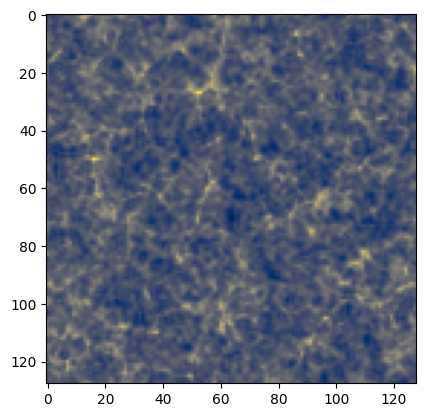

In [10]:
train_example = train_data[0]
print(f"Train example keys: {train_example['lr'].density_grid.shape}, {train_example['lr'].positions.shape}, {train_example['lr'].velocities.shape}")
plt.imshow(train_example["lr"].density_grid[0, :, :, 0],cmap='cividis')

In [11]:
print(vars(train_example["lr"]).keys())

dict_keys(['mesh', 'positions', 'velocities', 'potential', 'potential_grid', 'density_grid', 'grid'])


In [13]:
grid_input_init = jnp.stack(
    [train_example["lr"].potential_grid[0], train_example["lr"].density_grid[0]],
    axis=-1
)

In [14]:
loss_fn = build_loss_fn(
        config.training,
        neural_net,
        cosmology,
        correction_type=config.correction_model.type,
        mesh_lr=train_data[0]["lr"].mesh,
    )

2026-02-27 19:53:51,105 - INFO - Building loss function for training with loss type: mse_potential
2026-02-27 19:53:51,107 - INFO - Correction model type for loss function: cnn
2026-02-27 19:53:51,107 - INFO - JIT compiling potential loss function.
2026-02-27 19:53:51,107 - INFO - Correction model type: cnn
2026-02-27 19:53:51,108 - INFO - Using MSE loss on potential (trajectory loss).


In [15]:
params = initialize_network(
        train_data[0], neural_net=neural_net, model_type=config.correction_model.type
    )

2026-02-27 19:53:53,027 - INFO - Initializing network parameters with seed 42 for model type cnn


2026-02-27 19:53:53,738 - INFO - Initializing only the CNN correction model parameters.
/cosmos_storage/home/diegovillalba/JaxPM/.venv/lib/python3.11/site-packages/haiku/_src/base.py:664: UserWarning: Explicitly requested dtype float64 requested in ones is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  param = init(shape, dtype)
/cosmos_storage/home/diegovillalba/JaxPM/.venv/lib/python3.11/site-packages/haiku/_src/base.py:664: UserWarning: Explicitly requested dtype float64 requested in zeros is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  param = init(shape, dtype)


In [16]:
schedule = build_schedule(config.training.schedule)
optimizer, opt_state = build_optimizer(
        config.training, params=params, schedule=schedule
    )

In [17]:
print_initial_lr_loss(val_data)

early_stop = EarlyStopping(patience=config.training.patience)
best_params = params
best_loss = float("inf")

2026-02-27 19:54:04,821 - INFO - Calculating initial loss on validation set with untrained model...


2026-02-27 19:54:05,635 - INFO - Positions MSE  = 0.21603
2026-02-27 19:54:05,637 - INFO - Velocities MSE = 0.06814
2026-02-27 19:54:05,638 - INFO - Potential MSE  = 0.70997


In [18]:
# ==========================================
# CELL 1: SETUP & EXTRACCIÓN DEL PRIMER LOTE
# ==========================================

# 1. Definimos el wrapper para que JAX pueda derivar respecto a 'params'
def train_loss_fn(p, batch, sf, midx):
    # Nota: extraemos el [0] porque loss_fn devuelve (loss, aux_data)
    return loss_fn(params=p, dataset=batch, scale_factors=sf, max_idx=midx)

# 2. Simulamos la selección dinámica del snapshot
# rng = jax.random.PRNGKey(42) # Semilla fija para debug
# if config.training.sample_snapshots:
#     rng, _ = jax.random.split(rng)
#     # max_idx = jax.random.randint(
#     #     rng, minval=10, maxval=len(scale_factors), shape=(1,)
#     # )[0]
#     max_idx = jnp.asarray(len(scale_factors)-1, dtype=jnp.int32)
# else:
#     max_idx = None

max_idx = jnp.asarray(len(scale_factors)-1, dtype=jnp.int32)
# 3. Extraemos UN SOLO batch manualmente
batch = next(train_data.iterator)
batch = train_data.move_to_device(batch, device=jax.devices()[0])

print(f"Max Index seleccionado: {max_idx}")
print(f"Shape de Posiciones LR: {batch['lr'].positions.shape}")
print(f"Shape de Posiciones HR (Target): {batch['hr'].positions.shape}")

Max Index seleccionado: 49
Shape de Posiciones LR: (50, 2097152, 3)
Shape de Posiciones HR (Target): (50, 2097152, 3)


In [19]:
import subprocess

def gpu_mem_mib():
    out = subprocess.check_output(
        ["nvidia-smi", "--query-gpu=memory.used,memory.total", "--format=csv,nounits,noheader"]
    ).decode().strip().splitlines()
    # si hay varias GPUs, toma la 0
    used, total = out[0].split(",")
    return int(used), int(total)

def print_gpu_mem(tag=""):
    used, total = gpu_mem_mib()
    print(f"[GPU mem] {tag}: {used} MiB / {total} MiB")
import numpy as np
import jax
import jax.numpy as jnp
import jax.tree_util as tree

def pytree_nbytes(pytree):
    leaves = tree.tree_leaves(pytree)
    n = 0
    for x in leaves:
        # JAX array / numpy array / python scalar
        if hasattr(x, "dtype") and hasattr(x, "shape"):
            n += np.prod(x.shape) * np.dtype(x.dtype).itemsize
    return int(n)

def pretty_bytes(n):
    for unit in ["B","KiB","MiB","GiB","TiB"]:
        if n < 1024:
            return f"{n:.2f} {unit}"
        n /= 1024
    return f"{n:.2f} PiB"

def print_pytree_bytes(name, pytree):
    print(f"[{name}] approx bytes = {pretty_bytes(pytree_nbytes(pytree))}")

In [20]:
import numpy as np

def arr_bytes(x):
    return int(np.prod(x.shape)) * np.dtype(x.dtype).itemsize

def resolution_bytes(rd):
    total = 0
    total += arr_bytes(rd.positions)
    total += arr_bytes(rd.velocities)
    total += arr_bytes(rd.potential)
    if getattr(rd, "potential_grid", None) is not None:
        total += arr_bytes(rd.potential_grid)
    if getattr(rd, "density_grid", None) is not None:
        total += arr_bytes(rd.density_grid)
    if getattr(rd, "grid", None) is not None:
        total += arr_bytes(rd.grid)
    return total

def print_batch_bytes(batch):
    lr = batch["lr"]; hr = batch["hr"]
    print("LR batch bytes:", lr.positions.shape, lr.positions.dtype, resolution_bytes(lr)/1024**3, "GiB")
    print("HR batch bytes:", hr.positions.shape, hr.positions.dtype, resolution_bytes(hr)/1024**3, "GiB")

print_batch_bytes(batch)

LR batch bytes: (50, 2097152, 3) float32 4.296875 GiB
HR batch bytes: (50, 2097152, 3) float32 2.734375 GiB


In [21]:
os.environ["JAX_LOG_COMPILES"] = "1.0"
os.environ["JAX_TRACEBACK_FILTERING"] = "off"

In [22]:
def info(name, x):
    print(f"{name}: type={type(x)} shape={getattr(x,'shape',None)} ndim={getattr(x,'ndim',None)}")

info("scale_factors", scale_factors)
info("max_idx", max_idx)

lr = batch["lr"]; hr = batch["hr"]
info("lr.positions", lr.positions)
info("lr.velocities", lr.velocities)
info("hr.positions", hr.positions)
info("hr.velocities", hr.velocities)

# si usas grid en loss
info("lr.potential_grid", lr.potential_grid)
info("lr.density_grid", lr.density_grid)
info("lr.grid", lr.grid)

scale_factors: type=<class 'jaxlib._jax.ArrayImpl'> shape=(50,) ndim=1
max_idx: type=<class 'jaxlib._jax.ArrayImpl'> shape=() ndim=0
lr.positions: type=<class 'jaxlib._jax.ArrayImpl'> shape=(50, 2097152, 3) ndim=3
lr.velocities: type=<class 'jaxlib._jax.ArrayImpl'> shape=(50, 2097152, 3) ndim=3
hr.positions: type=<class 'jaxlib._jax.ArrayImpl'> shape=(50, 2097152, 3) ndim=3
hr.velocities: type=<class 'jaxlib._jax.ArrayImpl'> shape=(50, 2097152, 3) ndim=3
lr.potential_grid: type=<class 'jaxlib._jax.ArrayImpl'> shape=(50, 128, 128, 128) ndim=4
lr.density_grid: type=<class 'jaxlib._jax.ArrayImpl'> shape=(50, 128, 128, 128) ndim=4
lr.grid: type=<class 'jaxlib._jax.ArrayImpl'> shape=(50, 128, 128, 128, 2) ndim=5


In [23]:
# ==========================================
# CELL 2: FORWARD PASS & GRADIENTES (MEM DEBUG)
# ==========================================

print_gpu_mem("before forward")

print_pytree_bytes("params", params)
print_pytree_bytes("batch", batch)  # ojo: si batch incluye simulación completa, aquí se ve enorme

# Ensure all arrays in batch are on the same device (GPU)
# from jax import device_put
# def move_batch_to_device(batch, device):
#     for res in ['lr', 'hr']:
#         for attr in ['grid', 'positions', 'velocities', 'potential', 'potential_grid', 'density_grid']:
#             if hasattr(batch[res], attr):
#                 arr = getattr(batch[res], attr)
#                 if hasattr(arr, 'device') and arr.device != device:
#                     setattr(batch[res], attr, device_put(arr, device))
#     return batch
print("scale_factors:", type(scale_factors), getattr(scale_factors, "shape", None), scale_factors)
print("max_idx:", type(max_idx), getattr(max_idx, "shape", None), max_idx)

# batch = move_batch_to_device(batch, jax.devices()[0])

# Forward + grad
train_loss, grads = jax.value_and_grad(train_loss_fn)(params, batch, scale_factors, max_idx)

# Sync (muy importante)
train_loss.block_until_ready()

print_gpu_mem("after forward+grad")

print(f"Pérdida (Loss) del Batch: {float(train_loss):.5f}")

print_pytree_bytes("grads", grads)

# Opcional: inspeccionar el top-10 grad tensors más grandes
leaves = tree.tree_leaves(grads)
sizes = []
for i, x in enumerate(leaves):
    if hasattr(x, "shape") and hasattr(x, "dtype"):
        sizes.append((i, int(np.prod(x.shape) * np.dtype(x.dtype).itemsize), x.shape, x.dtype))
sizes.sort(key=lambda t: t[1], reverse=True)

print("\nTop 10 grad leaves by size:")
for i, nb, shape, dtype in sizes[:10]:
    print(f"  leaf {i:03d}: {pretty_bytes(nb)}  shape={shape} dtype={dtype}")

# Tu check de norms (con cuidado: linalg.norm en arrays grandes también aloca)
grad_norms = tree.tree_map(lambda x: jnp.linalg.norm(x).block_until_ready() if hasattr(x, "shape") else x, grads)

print("\nGrad norms (flattened):")
for norm in tree.tree_leaves(grad_norms)[:20]:
    print(float(norm))

[GPU mem] before forward: 8794 MiB / 97887 MiB
[params] approx bytes = 66.39 KiB
[batch] approx bytes = 0.00 B
scale_factors: <class 'jaxlib._jax.ArrayImpl'> (50,) [0.1        0.11836734 0.1367347  0.15510204 0.1734694  0.19183673
 0.21020408 0.22857143 0.24693878 0.26530612 0.28367347 0.30204082
 0.32040817 0.33877552 0.35714287 0.37551022 0.39387757 0.4122449
 0.43061224 0.4489796  0.46734694 0.4857143  0.5040816  0.52244896
 0.5408163  0.55918366 0.577551   0.59591836 0.6142857  0.63265306
 0.6510204  0.66938776 0.6877551  0.70612246 0.7244898  0.74285716
 0.7612245  0.77959186 0.7979592  0.81632656 0.83469385 0.8530612
 0.87142855 0.8897959  0.90816325 0.9265306  0.94489795 0.9632653
 0.98163265 1.        ]
max_idx: <class 'jaxlib._jax.ArrayImpl'> () 49


E0227 19:54:39.219728 2203357 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0227 19:54:40.432854 2203357 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


[GPU mem] after forward+grad: 87578 MiB / 97887 MiB
Pérdida (Loss) del Batch: 93.03959
[grads] approx bytes = 66.39 KiB

Top 10 grad leaves by size:
  leaf 007: 27.00 KiB  shape=(3, 3, 3, 16, 16) dtype=float32
  leaf 013: 27.00 KiB  shape=(3, 3, 3, 16, 16) dtype=float32
  leaf 001: 3.38 KiB  shape=(3, 3, 3, 2, 16) dtype=float32
  leaf 019: 2.19 KiB  shape=(35, 16) dtype=float32
  leaf 005: 1.00 KiB  shape=(16, 16) dtype=float32
  leaf 009: 1.00 KiB  shape=(16, 16) dtype=float32
  leaf 011: 1.00 KiB  shape=(16, 16) dtype=float32
  leaf 015: 1.00 KiB  shape=(16, 16) dtype=float32
  leaf 017: 1.00 KiB  shape=(16, 16) dtype=float32
  leaf 021: 1.00 KiB  shape=(16, 16) dtype=float32

Grad norms (flattened):
0.5617948174476624
25.19568634033203
0.5286267995834351
0.09913471341133118
1.018257737159729
0.5935715436935425
0.8060504198074341
69.23262023925781
0.5597436428070068
0.2673738896846771
1.068777322769165
0.3404364287853241
1.225393295288086
103.84626770019531
0.0
0.0
0.0
0.0
0.0
20.196

In [24]:
# ==========================================
# CELL 3: OPTIMIZER UPDATE (OPTILAX / OPTAX)
# ==========================================

# 1. Calculamos cómo deben cambiar los pesos basándonos en los gradientes
updates, opt_state = optimizer.update(grads, opt_state, params)

# 2. Aplicamos esos cambios a nuestra red neuronal
params = optax.apply_updates(params, updates)

print("¡Pesos actualizados exitosamente!")

# Si tu learning rate usa un schedule dinámico (cosine decay), podemos verlo así:
try:
    current_lr = opt_state.inner_opt_state[1].hyperparams["learning_rate"]
    print(f"Learning Rate actual: {current_lr}")
except AttributeError:
    print("Learning Rate es estático o la estructura del opt_state es diferente.")

¡Pesos actualizados exitosamente!
Learning Rate actual: 0.0


In [25]:
from tqdm.notebook import tqdm

n_debug_steps = 100
pbar_debug = tqdm(range(n_debug_steps), desc="Entrenando mini-bucle (mem-debug)")

print_gpu_mem("start")
print_pytree_bytes("params (static)", params)

# TIP: fija max_idx para ver si el crecimiento es por recompilación
# fixed_max_idx = jnp.asarray(len(scale_factors)-1, dtype=jnp.int32)

for step in pbar_debug:
    # 1) max_idx
    if config.training.sample_snapshots:
        # rng, _ = jax.random.split(rng)
        # max_idx = jax.random.randint(
        #     rng, minval=10, maxval=len(scale_factors), shape=(1,), dtype=jnp.int32
        # )[0]
        max_idx = jnp.asarray(20, dtype=jnp.int32)
    else:
        max_idx = jnp.asarray(len(scale_factors)-1, dtype=jnp.int32)

    # 2) batch
    batch = next(train_data.iterator)

    # Diagnóstico: tamaño del batch en bytes (CPU o GPU)
    if step == 0:
        print_pytree_bytes("batch (before move)", batch)

    batch = train_data.move_to_device(batch, device=jax.devices()[0])

    if step == 0:
        # imprime shapes clave para confirmar si estás moviendo trayectoria completa
        print("LR positions:", batch["lr"].positions.shape, batch["lr"].positions.dtype,
              "device:", batch["lr"].positions.device)
        print("HR positions:", batch["hr"].positions.shape, batch["hr"].positions.dtype,
              "device:", batch["hr"].positions.device)
        if getattr(batch["lr"], "potential_grid", None) is not None:
            print("LR pot_grid:", batch["lr"].potential_grid.shape, batch["lr"].potential_grid.dtype,
                  "device:", batch["lr"].potential_grid.device)
        if getattr(batch["lr"], "density_grid", None) is not None:
            print("LR dens_grid:", batch["lr"].density_grid.shape, batch["lr"].density_grid.dtype,
                  "device:", batch["lr"].density_grid.device)

    # 3) forward+grad (medimos memoria antes y después)
    print_gpu_mem(f"step {step} before fwd")

    train_loss, grads = jax.value_and_grad(train_loss_fn)(params, batch, scale_factors, max_idx)

    # 🔴 sincroniza para que la medición sea real
    train_loss.block_until_ready()
    print_gpu_mem(f"step {step} after fwd+grad")

    # 4) optim update (también puede alocar)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)

    # sincroniza una hoja de grads (opcional) para medir post-update
    # (bloquea usando un leaf pequeño o el loss ya sirve)
    train_loss.block_until_ready()
    print_gpu_mem(f"step {step} after update")

    pbar_debug.set_postfix({"Loss": f"{float(train_loss):.5f}", "max_idx": int(max_idx)})

    # 5) chequeo rápido de crecimiento sostenido
    if step == 0:
        print_pytree_bytes("grads (step0)", grads)

    # ✅ evita retener referencias: borra explícitamente
    del grads, updates, batch

    if step > 0 and step % 10 == 0:
        print(f"Step {step} | Loss: {float(train_loss):.5f} | max_idx={int(max_idx)}")

print_gpu_mem("end")
print("¡Mini-entrenamiento completado!")

Entrenando mini-bucle (mem-debug):   0%|          | 0/100 [00:00<?, ?it/s]

[GPU mem] start: 87578 MiB / 97887 MiB
[params (static)] approx bytes = 66.39 KiB
[batch (before move)] approx bytes = 0.00 B
LR positions: (50, 2097152, 3) float32 device: cuda:0
HR positions: (50, 2097152, 3) float32 device: cuda:0
LR pot_grid: (50, 128, 128, 128) float32 device: cuda:0
LR dens_grid: (50, 128, 128, 128) float32 device: cuda:0
[GPU mem] step 0 before fwd: 87578 MiB / 97887 MiB
[GPU mem] step 0 after fwd+grad: 87586 MiB / 97887 MiB
[GPU mem] step 0 after update: 87586 MiB / 97887 MiB
[grads (step0)] approx bytes = 66.39 KiB
[GPU mem] step 1 before fwd: 87586 MiB / 97887 MiB
[GPU mem] step 1 after fwd+grad: 87586 MiB / 97887 MiB
[GPU mem] step 1 after update: 87586 MiB / 97887 MiB
[GPU mem] step 2 before fwd: 87586 MiB / 97887 MiB
[GPU mem] step 2 after fwd+grad: 87586 MiB / 97887 MiB
[GPU mem] step 2 after update: 87586 MiB / 97887 MiB
[GPU mem] step 3 before fwd: 87586 MiB / 97887 MiB
[GPU mem] step 3 after fwd+grad: 87586 MiB / 97887 MiB
[GPU mem] step 3 after update

KeyboardInterrupt: 

In [26]:
# ==========================================
# CELL 4: EVALUACIÓN / VALIDACIÓN MÚLTIPLE
# ==========================================

val_loss_total = 0.0

# Iteramos sobre todo el conjunto de validación
for val_batch in val_data:
    val_batch = val_data.move_to_device(val_batch, device=jax.devices()[0])
    
    # Nota: Aquí llamamos a loss_fn DIRECTAMENTE, sin value_and_grad
    # vl es el loss, val_pos_pm son las posiciones corregidas que devuelve tu función
    vl, val_pos_pm = loss_fn(params, val_batch, scale_factors, max_idx=max_idx)
    val_loss_total += vl

val_loss_mean = val_loss_total / len(val_data)
print(f"Validation Loss Media: {val_loss_mean:.5f}")

# Opcional: Probar tu función de graficado (asegúrate de que plt.show() funcione en el notebook)
plot_eval(val_pos_pm, val_batch, max_idx=max_idx, fig_label="debug_val",use_wandb=False,plot_log=True,slab_thickness=128)

TypeError: iteration over a 0-d array

In [49]:
# ==========================================
# CELL 5: TEST SET & CHECKPOINTING
# ==========================================

# 1. Probar guardado local
# OJO: Asegúrate de que run_dir esté definido antes
print("Guardando checkpoint de prueba...")
# checkpoint(run_dir="/cosmos_storage/home/diegovillalba/JaxPM/models", loss=train_loss, params=params, prefix="debug_train", step=1)

# 2. Extraer un lote del Test Set
test_batch = val_data.move_to_device(test_data[0], device=jax.devices()[0])

# 3. Evaluar
test_loss, test_pos_pm = loss_fn(params, test_batch, scale_factors, max_idx=None)

print(f"Test Loss del modelo actual: {test_loss:.5f}")

Guardando checkpoint de prueba...


2026-02-26 23:32:46,816 - INFO - Initializing CNN correction model with config:
2026-02-26 23:32:46,817 - INFO -   channels_hidden_dim: 16
2026-02-26 23:32:46,817 - INFO -   n_convolutions: 3
2026-02-26 23:32:46,818 - INFO -   n_fully_connected: 2
2026-02-26 23:32:46,818 - INFO -   input_dim: 1
2026-02-26 23:32:46,819 - INFO -   kernel_size: 3
2026-02-26 23:32:46,819 - INFO -   pad_periodic: True
2026-02-26 23:32:46,819 - INFO -   embed_globals: False
2026-02-26 23:32:46,820 - INFO -   n_globals_embedding: 1
2026-02-26 23:32:46,821 - INFO -   globals_embedding_dim: 64
2026-02-26 23:32:46,821 - INFO -   global_conditioning: add
2026-02-26 23:32:46,821 - INFO -   use_attention_interpolation: False
2026-02-26 23:32:46,822 - INFO -   add_particle_velocities: True


Test Loss del modelo actual: 0.75282


In [ ]:
def train(config=None, data_dir=DEFAULT_DATA_DIR, output_dir=DEFAULT_MODEL_DIR):
    neural_net = build_network(config.correction_model)
    cosmology, scale_factors, train_data, val_data, test_data = build_dataloader(
        config.data, data_dir=data_dir
    )

    print(
        f"Dataset summary: Train ({len(train_data)}), Val ({len(val_data)}), Test ({len(test_data)})"
    )

    params = initialize_network(
        train_data[0], neural_net=neural_net, model_type=config.correction_model.type
    )

    # Setup WandB and directory
    run = wandb.init(
        project=config.wandb.project, config=config.to_dict(), dir=output_dir
    )
    print(f"Run name: {run.name}")
    run_dir = output_dir / f"{run.name}"
    run_dir.mkdir(exist_ok=True, parents=True)

    with open(run_dir / "config.yaml", "w") as f:
        yaml.dump(config.to_dict(), f)

    loss_fn = build_loss_fn(
        config.training,
        neural_net,
        cosmology,
        correction_type=config.correction_model.type,
        mesh_lr=train_data[0]["lr"].mesh,
    )

    schedule = build_schedule(config.training.schedule)
    optimizer, opt_state = build_optimizer(
        config.training, params=params, schedule=schedule
    )

    print_initial_lr_loss(val_data)

    early_stop = EarlyStopping(patience=config.training.patience)
    best_params = params
    best_loss = float("inf")
    rng = jax.random.PRNGKey(0)

    # Value and Grad wrapper for single step
    def train_loss_fn(p, batch, sf, midx):
        return loss_fn(params=p, dataset=batch, scale_factors=sf, max_idx=midx)[0]

    pbar = tqdm(range(config.training.n_steps), desc="Training")

    for step in pbar:
        # 1. Prepare Batch & Dynamic Slices
        if config.training.sample_snapshots:
            rng, _ = jax.random.split(rng)
            max_idx = jax.random.randint(
                rng, minval=10, maxval=len(scale_factors), shape=(1,)
            )[0]
        else:
            max_idx = None

        batch = next(train_data.iterator)
        batch = train_data.move_to_device(batch, device=jax.devices()[0])

        # 2. Gradient Update
        train_loss, grads = jax.value_and_grad(train_loss_fn)(
            params, batch, scale_factors, max_idx
        )
        updates, opt_state = optimizer.update(grads, opt_state, params)
        params = optax.apply_updates(params, updates)

        pbar.set_postfix({"Loss": float(train_loss)})

        # 3. Validation & Checkpointing
        eval_freq = 10 * config.training.batch_size
        if step > 0 and step % eval_freq == 0:
            val_loss = 0.0
            for val_batch in val_data:
                val_batch = val_data.move_to_device(val_batch, device=jax.devices()[0])
                vl, val_pos_pm = loss_fn(
                    params, val_batch, scale_factors, max_idx=max_idx
                )
                val_loss += vl

            val_loss /= len(val_data)

            # Plot validation sample
            plot_eval(val_pos_pm, val_batch, max_idx=max_idx)

            # Early stopping check
            early_stop = early_stop.update(val_loss)
            if early_stop.has_improved:
                best_params = params
                best_loss = val_loss

            # Step the schedule if it is a custom class that requires it
            if hasattr(schedule, "step"):
                schedule.step(val_loss)

            learning_rate = opt_state.inner_opt_state[1].hyperparams["learning_rate"]
            wandb.log(
                {
                    "train_loss": float(train_loss),
                    "val_loss": float(val_loss),
                    "learning_rate": float(learning_rate),
                },
                step=step,
            )

            pbar.set_postfix(
                {"train_loss": float(train_loss), "val_loss": float(val_loss)}
            )

            if early_stop.should_stop:
                print(f"Early stopping triggered at step {step}.")
                break

        # 4. Save Weights
        if step > 0 and step % config.training.checkpoint_every == 0:
            checkpoint(
                run_dir=run_dir,
                loss=train_loss,
                params=params,
                prefix="train",
                step=step,
            )

    # 5. Final Evaluation on Test Set
    checkpoint(run_dir=run_dir, params=best_params, loss=best_loss, prefix="best")

    test_batch = val_data.move_to_device(test_data[0], device=jax.devices()[0])
    test_loss, test_pos_pm = loss_fn(
        best_params, test_batch, scale_factors, max_idx=None
    )

    print(f"Test loss = {test_loss:.5f}")
    plot_eval(test_pos_pm, test_batch, max_idx=None, fig_label="test")

    wandb.finish()
    return best_loss